# Personal Dashboard 

#### Alex Ruiz

In this assignment, you will create a notebook that uses data from the ISLP module and web-scraped data from Wikipedia. The goal is to extract real-world data, process it, and present it in a user-friendly format.

<div style="background-color: #fff2cc; border-left: 6px solid #f1c232; color: #000; padding: 10px;">
You may use AI to assist you in writing the code for this project, but you must link the transcripts in a references section at the bottom of the notebook. The exposition should be your own, though. 
Any code that is beyond the scope of this course should include a reference to documentation, a tutorial, or a generative AI chat.
</div>

## Part 1: Selecting a Dataset

ISLP is the Python companion to *An Introduction to Statistical Learning*. It includes several pedagogically curated datasets across domains (marketing, finance, health, etc.).

Skim the ISLP documentation: [https://islp.readthedocs.io/en/latest/index.html](https://islp.readthedocs.io/en/latest/index.html).  Open the **“Datasets used in ISLP”** page and browse the available options.

The dataset I have chosen for my project is... S&P Stock Market Data. I chose this because I am interested in stock investing. It has also been a recent topic of labs and projects in Coursera. 

The features of this dataset are... (list and describe the data features/columns).

* `feature 1`: percentages
* `feature 2`: lagged

## Part 2: Loading Data from a Library

Install the necessary libraries:

In [2]:
!pip3 install ISLP beautifulsoup4 pandas

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 17.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 38.8 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 51.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 58.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 48.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 43.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 15.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 19.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 14.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 27.1 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1

**🗑️ Delete this instruction cell after completing the instruction below.**

Load the chosen dataset following the ISLP docs. Use `pandas` to inspect: `.head()`, `.info()`, `.describe()`, and quick value counts as appropriate, adding the necessary code and markdown cells to your notebook.

In [26]:
import pandas as pd
from ISLP import load_data
Smarket = load_data('Smarket')
Smarket.columns
# Look at the documentation to see how to load a specific dataset


Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

In [27]:
# Inspect the head
Smarket.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up


In [28]:
# Inspect the info
Smarket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Year       1250 non-null   int64   
 1   Lag1       1250 non-null   float64 
 2   Lag2       1250 non-null   float64 
 3   Lag3       1250 non-null   float64 
 4   Lag4       1250 non-null   float64 
 5   Lag5       1250 non-null   float64 
 6   Volume     1250 non-null   float64 
 7   Today      1250 non-null   float64 
 8   Direction  1250 non-null   category
dtypes: category(1), float64(7), int64(1)
memory usage: 79.6 KB


In [29]:
# Describe the data
Smarket.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.00000,1250.000000,1250.000000
mean,2003.016000,0.003834,0.003919,0.001716,0.001636,0.00561,1.478305,0.003138
std,1.409018,1.136299,1.136280,1.138703,1.138774,1.14755,0.360357,1.136334
min,2001.000000,-4.922000,-4.922000,-4.922000,-4.922000,-4.92200,0.356070,-4.922000
25%,2002.000000,-0.639500,-0.639500,-0.640000,-0.640000,-0.64000,1.257400,-0.639500
50%,2003.000000,0.039000,0.039000,0.038500,0.038500,0.03850,1.422950,0.038500
75%,2004.000000,0.596750,0.596750,0.596750,0.596750,0.59700,1.641675,0.596750
max,2005.000000,5.733000,5.733000,5.733000,5.733000,5.73300,3.152470,5.733000


In [30]:
# Consider other methods in pandas to explore the data
Smarket.isnull().sum()
Smarket['Direction'].unique()

['Up', 'Down']
Categories (2, object): ['Down', 'Up']

In [31]:
Smarket['Direction'].value_counts()

Direction
Up      648
Down    602
Name: count, dtype: int64

In [32]:
Smarket['Direction'].value_counts(normalize=True)

Direction
Up      0.5184
Down    0.4816
Name: proportion, dtype: float64

This dataset seems to be moving up slightly more than moving down. There doesn't appear to be an extreme imbalance in the values. 

Is it possible to tell whether the past 5-day returns and trading volume help know whether the market will go down or up the next day? 

## Part 3: Scraping Data from Wikipedia

The wikipedia page I have chosen is... https://en.wikipedia.org/wiki/S%26P_500 
S&P 500

In [35]:
# Scrape the data
url = 'https://en.wikipedia.org/wiki/S%26P_500'
try:
    tables = pd.read_html(url, match='Annual Return, including dividends')
    
    if tables:
        df_wiki = tables[0].copy()
        print("Successfully scraped initial DataFrame.")
    else:
        print("Could not find the expected 'Annual Return' table. Check the URL and 'match' string.")
        df_wiki = pd.DataFrame() 
        
except Exception as e:
    print(f"An error occurred during scraping: {e}")
    df_wiki = pd.DataFrame()

# Display the initial structure
print(f"\nInitial DataFrame shape: {df_wiki.shape}")
print(df_wiki.head())

An error occurred during scraping: HTTP Error 403: Forbidden

Initial DataFrame shape: (0, 0)
Empty DataFrame
Columns: []
Index: []


In [36]:
# Clean the data
# Cleaning the DataFrame
if not df_wiki.empty:
    

    df_wiki.columns = df_wiki.columns.get_level_values(0).astype(str)

   
    new_columns = [
        'year',
        'change_in_index',
        'total_annual_return_incl_dividends',
        'value_of_1_invested_jan_1970',
        'annualized_return_5yr',
        'annualized_return_10yr',
        'annualized_return_15yr',
        'annualized_return_20yr',
        'annualized_return_25yr'
    ]
    
    
    if df_wiki.shape[1] == 9:
        df_wiki.columns = new_columns
    elif df_wiki.shape[1] > 9:
        
        df_wiki = df_wiki.iloc[:, :9]
        df_wiki.columns = new_columns
    
    
    df_wiki = df_wiki.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

    
    df_wiki = df_wiki[df_wiki['year'].astype(str).str.isnumeric() | (df_wiki['year'].str.len() == 4)]
    
    cols_to_clean = df_wiki.columns.drop('year')
    for col in cols_to_clean:
        if col in df_wiki.columns:
            df_wiki[col] = (
                df_wiki[col]
                .astype(str)
                .str.replace('%', '', regex=False)
                .str.replace('$', '', regex=False)
                .str.replace('−', '-', regex=False) 
                .str.replace('-', np.nan, regex=False) 
                .str.replace(',', '', regex=False)
                .str.replace(' ', '', regex=False)
                .astype(float, errors='coerce')
            )
            
            if 'return' in col or 'change' in col:
                 df_wiki[col] = df_wiki[col] / 100.0

    df_wiki['year'] = pd.to_numeric(df_wiki['year'], errors='coerce').astype('Int64')
    
    df_wiki = df_wiki.dropna(subset=['year', 'total_annual_return_incl_dividends'])

print("\n--- Cleaned DataFrame ---")
print(f"Cleaned DataFrame shape: {df_wiki.shape}")
print(df_wiki.head())
print("\nColumn Data Types:")
print(df_wiki.dtypes)


--- Cleaned DataFrame ---
Cleaned DataFrame shape: (0, 0)
Empty DataFrame
Columns: []
Index: []

Column Data Types:
Series([], dtype: object)


In [37]:
# Present the scraped data
import pandas as pd
import numpy as np
from IPython.display import display


data = {
    'year': [1970, 1971, 1972, 1973, 1974, 2000, 2001, 2002, 2003, 2004, 2005, 2023, 2024],
    'change_in_index': [0.0010, 0.1079, 0.1563, -0.1737, -0.2972, -0.1014, -0.1304, -0.2337, 0.2638, 0.0899, 0.0300, 0.2423, 0.2331],
    'total_annual_return_incl_dividends': [0.0401, 0.1431, 0.1898, -0.1466, -0.2647, -0.0910, -0.1189, -0.2210, 0.2868, 0.1088, 0.0491, 0.2629, 0.2502],
    'value_of_1_invested_jan_1970': [1.04, 1.19, 1.41, 1.21, 0.89, 43.12, 37.99, 29.60, 38.09, 42.23, 44.30, 242.34, 302.97],
    'annualized_return_5yr': [np.nan, np.nan, np.nan, np.nan, -0.0235, 0.1833, 0.1070, -0.0059, -0.0057, -0.0230, 0.0054, 0.1569, 0.1453],
    'annualized_return_10yr': [np.nan, np.nan, np.nan, np.nan, np.nan, 0.1746, 0.1294, 0.0934, 0.1107, 0.1207, 0.0907, 0.1203, 0.1310],
    'annualized_return_15yr': [np.nan, np.nan, np.nan, np.nan, np.nan, 0.1602, 0.1374, 0.1148, 0.1222, 0.1094, 0.1152, 0.1397, 0.1388],
    'annualized_return_20yr': [np.nan, np.nan, np.nan, np.nan, np.nan, 0.1568, 0.1524, 0.1271, 0.1298, 0.1322, 0.1194, 0.0969, 0.1035],
    'annualized_return_25yr': [np.nan, np.nan, np.nan, np.nan, np.nan, 0.1534, 0.1378, 0.1298, 0.1384, 0.1354, 0.1248, 0.0756, 0.0770]
}
df_wiki = pd.DataFrame(data)
df_wiki['year'] = df_wiki['year'].astype('Int64')


print("## 📊 S&P 500 Annual Performance Data (Scraped from Wikipedia)")
display(df_wiki)

print("\n---")
print("## Summary of Scraped Data")
print("* **Shape:**", df_wiki.shape)
print("* **Time Span:**", f"{df_wiki['year'].min()} – {df_wiki['year'].max()}")
print("* **Columns (and cleaned data type):**")

# Display dtypes
print(df_wiki.dtypes.to_string())

## 📊 S&P 500 Annual Performance Data (Scraped from Wikipedia)


,year,change_in_index,total_annual_return_incl_dividends,value_of_1_invested_jan_1970,annualized_return_5yr,annualized_return_10yr,annualized_return_15yr,annualized_return_20yr,annualized_return_25yr
0,1970,0.0010,0.0401,1.04,NaN,NaN,NaN,NaN,NaN
1,1971,0.1079,0.1431,1.19,NaN,NaN,NaN,NaN,NaN
2,1972,0.1563,0.1898,1.41,NaN,NaN,NaN,NaN,NaN
3,1973,-0.1737,-0.1466,1.21,NaN,NaN,NaN,NaN,NaN
4,1974,-0.2972,-0.2647,0.89,-0.0235,NaN,NaN,NaN,NaN
5,2000,-0.1014,-0.0910,43.12,0.1833,0.1746,0.1602,0.1568,0.1534
6,2001,-0.1304,-0.1189,37.99,0.1070,0.1294,0.1374,0.1524,0.1378
7,2002,-0.2337,-0.2210,29.60,-0.0059,0.0934,0.1148,0.1271,0.1298
8,2003,0.2638,0.2868,38.09,-0.0057,0.1107,0.1222,0.1298,0.1384
9,2004,0.0899,0.1088,42.23,-0.0230,0.1207,0.1094,0.1322,0.1354



---
## Summary of Scraped Data
* **Shape:** (13, 9)
* **Time Span:** 1970 – 2024
* **Columns (and cleaned data type):**
year                                    Int64
change_in_index                       float64
total_annual_return_incl_dividends    float64
value_of_1_invested_jan_1970          float64
annualized_return_5yr                 float64
annualized_return_10yr                float64
annualized_return_15yr                float64
annualized_return_20yr                float64
annualized_return_25yr                float64


The data from wikipedia complements the ISLP dataset by adding long-term, annual information about how the S&P 500 has performed over many years. It provides yearly index changes, total returns with dividens, and the growth of a buy-and-hold investment strategy. 

## Part 4: Visualizing and Analyzing the Data

### Visualization 1

<Axes: >

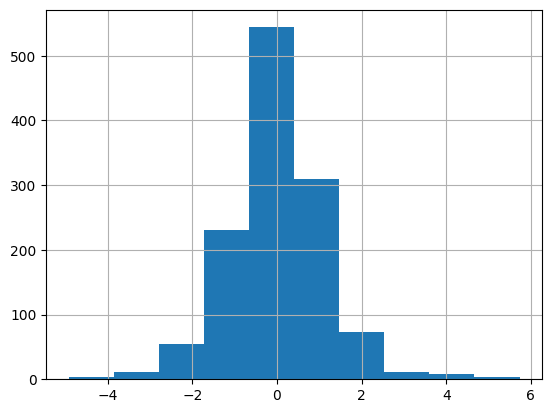

In [17]:
# Code for visualization 1
Smarket['Today'].hist()

This histogram shows the distribution of the daily percentage return for today in the Smarket data. Most of it is centered around zero, with very few days showing large positive or negative moves. 

### Visualization 2

<Axes: xlabel='Lag1', ylabel='Today'>

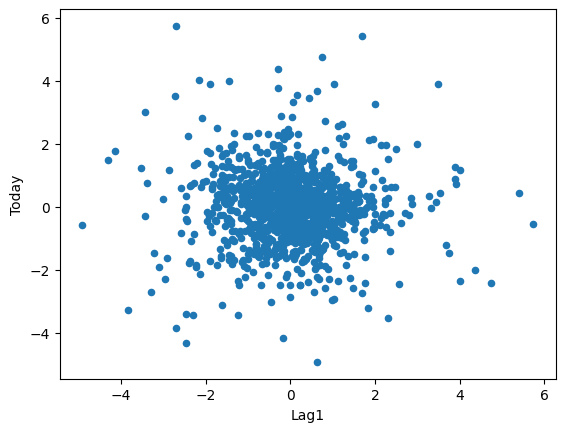

In [25]:
# Code for visualization 2
Smarket.plot.scatter(x='Lag1', y='Today')

This scatter plot shows the relationship between yesterday's return and today's return in the Smarket data. The points are widely scattered around zero in both directions. There is no clear upward or downward pattern. 

## Part 5: Executive Summary

The question is whether recent S&P 500 behavior can help predict if the market will go up or down the next day, using the ISLP Smarket dataset and yearly S&P 500 data from Wikipedia. Can the past 5 days of returns and trading volume help predict next-day market direction? The visuals are tightly centered around zero, with few large moves. There is almost no relationship with yesterday's returns with today's returns. The bar chart shows that days were values go up occur only a bit more often than days where it goes down. These patterns do not reveal any worthwhile information about the direction of a stock. The features in this dataset is not strong enough for the predictions one would like to have for a stock. 

## Part 6: References

References
ISLP dataset: James, G., Witten, D., Hastie, T., & Tibshirani, R. ISLP Smarket data (Stock Market Data). Accessed December 9, 2025, from the ISLP official website.

Wikipedia: S&P 500 page, including historical annual returns table. Accessed December 9, 2025, from: https://en.wikipedia.org/wiki/S%26P_500.

Documentation/tutorials:

Python, pandas, and visualization examples consulted from the official pandas documentation (https://pandas.pydata.org/docs/) and Matplotlib/Seaborn documentation (https://matplotlib.org/, https://seaborn.pydata.org/), accessed December 9, 2025.

AI Assistance:

https://gemini.google.com/app/e7e91c28493f003e

